# Setup

In [1]:
"""02_baselines.ipynb — Splits, propensity, S-learner, T-learner.

We start with the plumbing (splits + propensity) and then train the two
simplest meta-learners. The point isn't to crown a winner; it's to
demonstrate the structural failure modes of each, which motivates the
more sophisticated estimators in Phase 3.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from uplift.data import load_raw
from uplift.splits import make_splits, save_splits, load_splits
from uplift.treatment import (
    FEATURE_COLS,
    get_features,
    make_binary_treatment,
    make_xty,
    naive_ate,
)
from uplift.propensity import (
    PropensityModel,
    estimate_propensity_cv,
    overlap_diagnostics,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

RNG = np.random.default_rng(42)

# Create and save the splits

In [2]:
df = load_raw()
splits = make_splits(df, seed=42)
save_splits(splits)

for name, sdf in splits.items():
    T = make_binary_treatment(sdf)
    print(f"{name:6s}  n={len(sdf):>6,}  treated_rate={T.mean():.4f}")

train   n=38,400  treated_rate=0.6671
val     n=12,800  treated_rate=0.6671
test    n=12,800  treated_rate=0.6671


# Verify naive ATEs are preserved across splits

In [3]:
print(f"{'split':6s}  {'visit ATE':>10s}  {'visit SE':>10s}  {'spend ATE':>10s}  {'spend SE':>10s}")
for name, sdf in splits.items():
    v = naive_ate(sdf, "visit")
    s = naive_ate(sdf, "spend")
    print(
        f"{name:6s}  "
        f"{v['ate']:>+10.4f}  {v['ate_se']:>10.4f}  "
        f"{s['ate']:>+10.4f}  {s['ate_se']:>10.4f}"
    )

split    visit ATE    visit SE   spend ATE    spend SE
train      +0.0634      0.0036     +0.4975      0.1476
val        +0.0519      0.0063     +0.8729      0.2552
test       +0.0622      0.0061     +0.6186      0.2357


# Fit the propensity model on train

In [4]:
train_df = splits["train"]
X_train = get_features(train_df)
T_train = make_binary_treatment(train_df)

propensity = PropensityModel().fit(X_train, T_train)

# In-sample predictions on train (for diagnostic plotting only — don't
# use these for downstream IPS, that requires out-of-fold).
p_train_in = propensity.predict(X_train)
print("In-sample propensity diagnostics:")
for k, v in overlap_diagnostics(p_train_in).items():
    print(f"  {k:25s} {v:.4f}")

In-sample propensity diagnostics:
  min                       0.4204
  max                       0.8604
  mean                      0.6671
  std                       0.0408
  frac_extreme              0.0000
  frac_in_unit_interval     1.0000


# Out-of-fold propensity for downstream use

In [5]:
p_train_oof = estimate_propensity_cv(X_train, T_train, n_splits=5)
print("Out-of-fold propensity diagnostics:")
for k, v in overlap_diagnostics(p_train_oof).items():
    print(f"  {k:25s} {v:.4f}")

# Save for Phase 4 (IPS, DR-learner)
np.save(PROJECT_ROOT / "data" / "processed" / "propensity_train_oof.npy", p_train_oof)

Out-of-fold propensity diagnostics:
  min                       0.4136
  max                       0.8861
  mean                      0.6668
  std                       0.0456
  frac_extreme              0.0000
  frac_in_unit_interval     1.0000


# Plot the propensity distribution

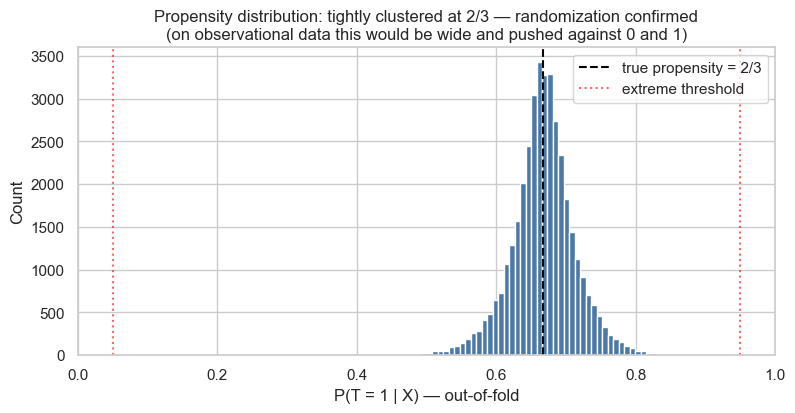

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(p_train_oof, bins=60, color="#4c78a8", edgecolor="white")
ax.axvline(2 / 3, color="black", linestyle="--", label="true propensity = 2/3")
ax.axvline(0.05, color="red", linestyle=":", alpha=0.6, label="extreme threshold")
ax.axvline(0.95, color="red", linestyle=":", alpha=0.6)
ax.set_xlabel("P(T = 1 | X) — out-of-fold")
ax.set_ylabel("Count")
ax.set_xlim(0, 1)
ax.set_title(
    "Propensity distribution: tightly clustered at 2/3 — randomization confirmed\n"
    "(on observational data this would be wide and pushed against 0 and 1)"
)
ax.legend(loc="upper right")
fig.savefig(FIG_DIR / "06_propensity_distribution.png")
plt.show()

# Cross-check: AUC and Feature Importance

In [7]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(T_train, p_train_oof)
print(f"Propensity model AUC: {auc:.4f}")
print(f"  (≈ 0.50 ⇒ treatment is unpredictable ⇒ randomization holds)\n")

importances = pd.Series(
    propensity.model.feature_importances_,
    index=propensity.feature_cols_,
).sort_values(ascending=False)
print("Top 10 'most predictive' features for treatment:")
print(importances.head(10))
print("\nNote: these are noise. Under randomization, NO feature should be")
print("meaningfully predictive of treatment. The model is fitting tiny")
print("residual fluctuations.")

Propensity model AUC: 0.5021
  (≈ 0.50 ⇒ treatment is unpredictable ⇒ randomization holds)

Top 10 'most predictive' features for treatment:
history                      2747
recency                      1256
mens                          357
channel_Phone                 326
zip_code_Surburban            311
zip_code_Urban                311
newbie                        301
channel_Web                   179
womens                        168
history_segment_3_200_350      11
dtype: int32

Note: these are noise. Under randomization, NO feature should be
meaningfully predictive of treatment. The model is fitting tiny
residual fluctuations.
